## Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## Define Dataset Path

In [2]:
dataset_path = "/Users/lenovo1/Documents/AI_Document_Classifier"

## Data Preprocessing + Augmentation (DATA POPULATION)

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2   # 80% train, 20% validation
)

## Load Training Data

In [4]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='training',
    classes=['Aadhar_Card', 'Pan_Card', '10th_Marksheet', '12th_Marksheet']
)

Found 32 images belonging to 4 classes.


## Load Validation Data

In [5]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='validation',
    classes=['Aadhar_Card', 'Pan_Card', '10th_Marksheet', '12th_Marksheet']
)

Found 8 images belonging to 4 classes.


## Check Class Labels

In [6]:
print(train_data.class_indices)

{'Aadhar_Card': 0, 'Pan_Card': 1, '10th_Marksheet': 2, '12th_Marksheet': 3}


## Build Model (MobileNetV2)

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load base model
base_model = MobileNetV2(weights='imagenet', include_top=False)

# Freeze layers (important)
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)   # 4 classes

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

9420800/9406464 [==============================] - 8s 1us/step


## Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
4/4 [==============================] - 4s 565ms/step - loss: 1.3837 - accuracy: 0.3438 - val_loss: 0.7580 - val_accuracy: 0.6250
Epoch 2/10
4/4 [==============================] - 1s 306ms/step - loss: 0.5473 - accuracy: 0.7500 - val_loss: 0.6368 - val_accuracy: 0.7500
Epoch 3/10
4/4 [==============================] - 1s 339ms/step - loss: 0.3839 - accuracy: 0.8438 - val_loss: 0.5840 - val_accuracy: 0.6250
Epoch 4/10
4/4 [==============================] - 1s 320ms/step - loss: 0.2845 - accuracy: 0.8750 - val_loss: 0.6246 - val_accuracy: 0.6250
Epoch 5/10
4/4 [==============================] - 1s 330ms/step - loss: 0.2728 - accuracy: 0.8750 - val_loss: 0.4849 - val_accuracy: 0.6250
Epoch 6/10
4/4 [==============================] - 1s 326ms/step - loss: 0.2386 - accuracy: 0.9062 - val_loss: 0.7000 - val_accuracy: 0.6250
Epoch 7/10
4/4 [==============================] - 1s 326ms/step - loss: 0.1446 - accuracy: 1.0000 - val_loss: 0.7848 - val_accuracy: 0.7500
Epoch 8/10
4/4 [====

## Plot Accuracy

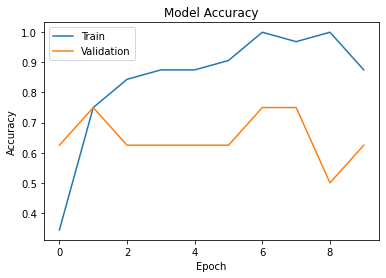

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

## Save Model

In [11]:
model.save("document_classifier.h5")

/Users/lenovo1/.local/lib/python3.8/site-packages/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


## Test Prediction on Single Image

In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/Users/lenovo1/Documents/AI_Document_Classifier/10th_Marksheet/1689501780799..jpg"   # put your test image path here

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

classes = list(train_data.class_indices.keys())

print("Predicted Class:", classes[np.argmax(prediction)])
print("Confidence:", np.max(prediction))

Predicted Class: 10th_Marksheet
Confidence: 0.8726302
